In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline, PchipInterpolator, UnivariateSpline, Akima1DInterpolator
from matplotlib import pyplot as plt
import pprint as pprint
#import papermill as pm
import scrapbook as sb

class bcolors:
    OK = "\033[92m"  # GREEN
    WARNING = "\033[93m"  # YELLOW
    FAIL = "\033[91m"  # RED
    RESET = "\033[0m"  # RESET COLOR

In [2]:
!pip install scrapbook

Defaulting to user installation because normal site-packages is not writeable


In [3]:
CutsType = "CutsType2"
run_to_analyze = "ag13687/ag13687.vertex.csv"
bkg_up = 0.0015
bkg_down = 0.0014

In [4]:
runs = {"2025": [run_to_analyze]}

mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center

In [5]:
def ReadTheCsv(filename, window):
    df = pd.read_csv(filename, delimiter=",") # read the dataset
    df = df.rename(columns={"Detector Time (detectors internal clock)": "Detector Time", "OfficialTime (run time)": "run time"})
    mask = (df[CutsType] == 1) & (df["Z"] > zmin) & ( df["Z"] < zmax)
    df_cleaned =  df.dropna()#[mask] # remove the Missing values for the dataset
    return df[mask]

def ReadTheSpill2(filename, window):
    # select the window events
    print(filename)
    occurrencies = 0
    with open(filename.replace(".vertex.csv", "_spill_log"), "r") as file:
        for line in file:
            if(window in line):
                print(line)
                occurrencies += 1
                if(occurrencies > 1): print(bcolors.WARNING + f"ATTENTION, TWO ENTRIES IN SPILLOG {filename}" + bcolors.RESET)
    
    stop  = []
    start = []
    counter = 1
    with open(filename.replace(".vertex.csv", "_spill_log"), "r") as file:
        for line in file:
            if (window in line):
                counter += 1
                if(counter >0):
                    parts = line.strip().split("=")
                    starter = parts[0].replace('[', '').replace(']','').split("-")[0]
                    stopper = parts[0].replace('[', '').replace(']','').split("-")[1]
                    start.append(float(starter))
                    stop.append(float(stopper))
                    print(f"   {parts[0]},{parts[1]}...")
 
    return start, stop

def append_to_dict(dictionary, key, item):
    if key in dictionary.keys():
        dictionary[key].append(item)
    else:
        dictionary.update({key : [item]})

# estimate background

In [6]:
if(True):
    datacosm = ReadTheCsv("ag13628/ag13628.vertex.csv",  "-1")
    mask_down = (datacosm["Z"] < zgap_min)
    bkg_down = (mask_down.sum())/7200
    mask_up = (datacosm["Z"] > zgap_max)
    bkg_up = (mask_up.sum())/7200
    print(f"Bkg estimated: up region {bkg_up:.4f} Hz down region {bkg_down:.4f} Hz")

Bkg estimated: up region 0.0010 Hz down region 0.0008 Hz


In [7]:
data = ReadTheCsv(runs["2025"][0],  "-1")

start_clear, stop_clear = ReadTheSpill2(runs["2025"][0], "\"Fast Clear\"[0]")
start_knife_cb, stop_knife_cb = ReadTheSpill2(runs["2025"][0], "\"Microwave Dump\"[0]")
start_knife_da, stop_knife_da = ReadTheSpill2(runs["2025"][0], "\"Microwave Dump\"[1]")
start_adiabatic, stop_adiabatic = ReadTheSpill2(runs["2025"][0],"\"Adiabatic Expansion\"[0]")
start_magb_rampdown, stop_magb_rampdown = ReadTheSpill2(runs["2025"][0],"\"MAGB Tickle RampDown\"[0]")
start_magb_rampdown1, stop_magb_rampdown1 = ReadTheSpill2(runs["2025"][0],"\"MAGB Tickle RampDown\"[1]")
start_magb_rampdown2, stop_magb_rampdown2 = ReadTheSpill2(runs["2025"][0],"\"MAGB Tickle RampDown\"[2]")
start_magb_rampdown3, stop_magb_rampdown3 = ReadTheSpill2(runs["2025"][0],"\"MAGB Tickle RampDown\"[3]")
start_magb_rampdown4, stop_magb_rampdown4 = ReadTheSpill2(runs["2025"][0],"\"MAGB Tickle RampDown\"[4]")
endrun = float(7813)
print(start_knife_cb)
print(start_clear)

ag13687/ag13687.vertex.csv
   [13674.553-13674.578]=   0.025s |          "Fast Clear"[0]          |       4        0        0        0        0        0        8       17       26         0 

   [13674.553-13674.578],   0.025s |          "Fast Clear"[0]          |       4        0        0        0        0        0        8       17       26         0...
ag13687/ag13687.vertex.csv
   [16761.242-17017.257]= 256.015s |          "Microwave Dump"[0]      |   34638     1507     1394      886    13636    10118    31783    19335    52567       196 

   [16761.242-17017.257], 256.015s |          "Microwave Dump"[0]      |   34638     1507     1394      886    13636    10118    31783    19335    52567       196...
ag13687/ag13687.vertex.csv
ag13687/ag13687.vertex.csv
   [13867.229-13928.432]=  61.203s |          "Adiabatic Expansion"[0] |    9046      366      320      190     2994     2168     6660     4445    11475        18 

   [13867.229-13928.432],  61.203s |          "Adiabatic Expansio

[200]
bin time 25.326264290000836
no second Microwave dump


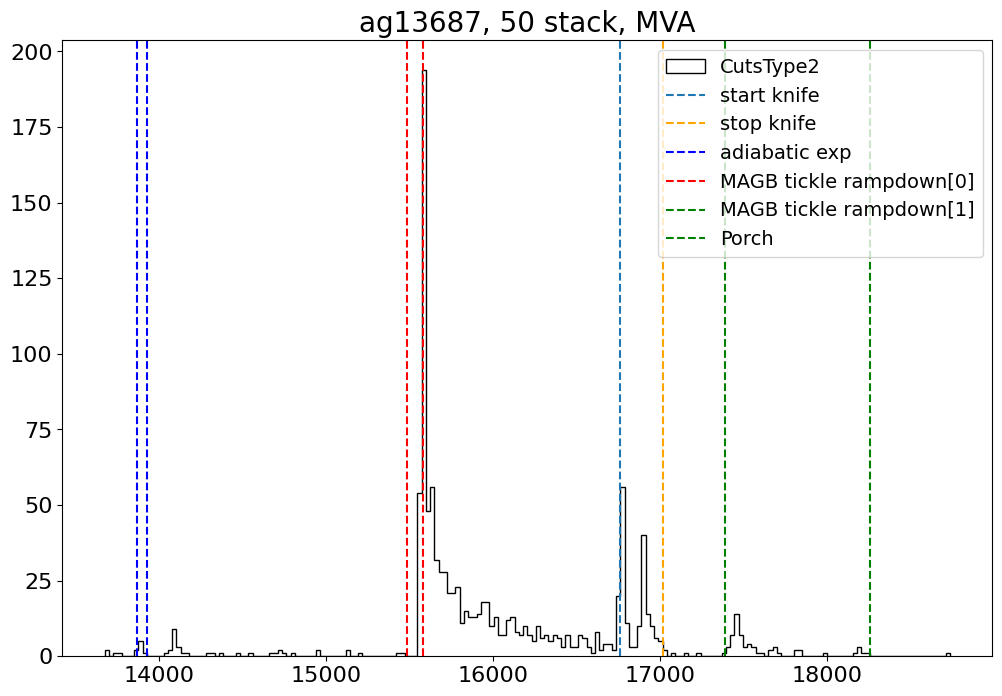

In [8]:
binning = np.array([200])
print(binning)

plt.figure(0, figsize = (12, 8))
plt.title(f"ag{runs['2025'][0].split('/')[0].replace('ag','')}, 50 stack, MVA", fontsize = 20)
plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)
#plt.ylim(0,30)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], histtype = "step", color = "black", density = False, label = f"{CutsType}",)

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_knife_cb[0], linestyle = "--", label = "start knife")
plt.axvline(stop_knife_cb[0], linestyle = "--", color = "orange", label = "stop knife")

try: 
    plt.axvline(start_knife_da[0], linestyle = "--", label = "start knife da")
    plt.axvline(stop_knife_da[0], linestyle = "--", color = "orange")
except:
    print("no second Microwave dump")


plt.axvline(start_adiabatic[0], linestyle = "--", color = "blue", label = "adiabatic exp")
plt.axvline(stop_adiabatic[0], linestyle = "--", color = "blue")

plt.axvline(start_magb_rampdown[0], linestyle = "--", color = "red", label = "MAGB tickle rampdown[0]")
plt.axvline(stop_magb_rampdown[0], linestyle = "--", color = "red")

plt.axvline(start_magb_rampdown1[0], linestyle = "--", label = "MAGB tickle rampdown[1]", color = "green")
plt.axvline(stop_magb_rampdown4[0], linestyle = "--", label = "Porch", color = "green")

#plt.ylim(0,30)

plt.legend( fontsize = 14, loc = "upper right")
plt.savefig(f"Summary_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

60 60
[False False False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]
[11791.86894654   350.78289512]


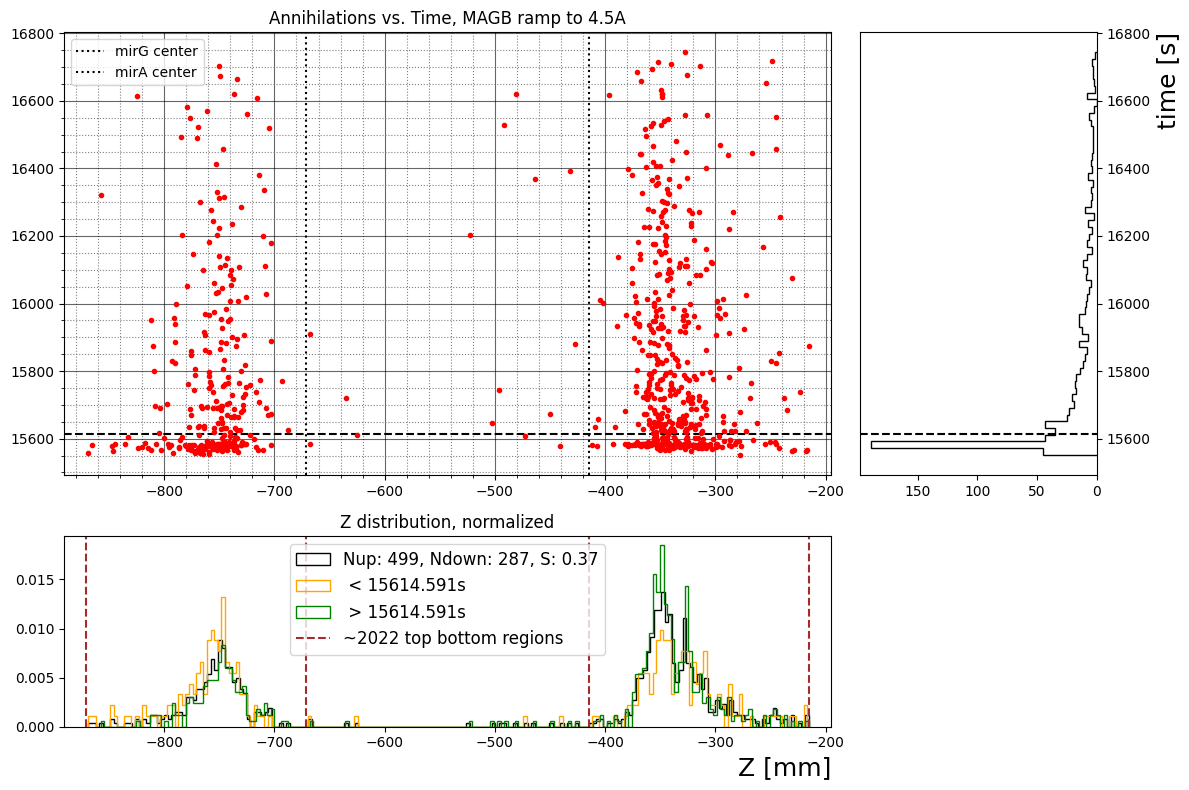

In [9]:
#plt.figure(0, figsize = (12, 8))
#plt.title("R13659, Adiabatic Expantion", fontsize = 20)
#plt.yticks(fontsize = 16)
#plt.xticks(fontsize = 16)

def expf(x, A, tau):
    return A*1/tau*np.exp(-x/tau)


timecut = stop_magb_rampdown[0] + 30

def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):

    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

mask = (data["run time"] > start_magb_rampdown[0]) & (data["run time"] < start_knife_cb[0])
mask_time = (data["run time"] > start_magb_rampdown[0]) & (data["run time"] < timecut)
mask_time_neg = (data["run time"] < start_knife_cb[0]) & (data["run time"] > timecut)

Nup, Ndown = NupNdown(data, start_magb_rampdown[0], start_knife_cb[0], zmin, zmax, zgap_min, zgap_max)

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.set_title("Annihilations vs. Time, MAGB ramp to 4.5A")

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "red", marker = ".", linestyle = "")
# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
ax1.axhline(timecut, linestyle = "--", color = "black")
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")
ax1.set_xlim(zmin-20,zmax+20)
ax1.legend()


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {Nup}, Ndown: {Ndown}, S: {S:.2}")
ax2.hist(data["Z"][mask_time], bins = binning[0], histtype = "step", color = "orange", density = True,  label = f" < {timecut}s")
ax2.hist(data["Z"][mask_time_neg], bins = binning[0], histtype = "step", color = "green", density = True,  label = f" > {timecut}s ")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)

counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')
print(len(bins[:-1]), len(counts))
mask_fit = (bins[:-1] > timecut)
print(mask_fit)
popt, pcovm = curve_fit(expf,(bins[:-1] - bins[0])[mask_fit], counts[mask_fit], p0 = [100, 20])
print(popt)
xgrid = np.linspace(bins[4], bins[-1], 100)
#print(xgrid)
#ax3.plot(expf(xgrid - xgrid[0], *popt),xgrid, linestyle = "--", color = "red" )

ax3.axhline(timecut, linestyle = "--", color = "black")
#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"AdiabaticExp_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

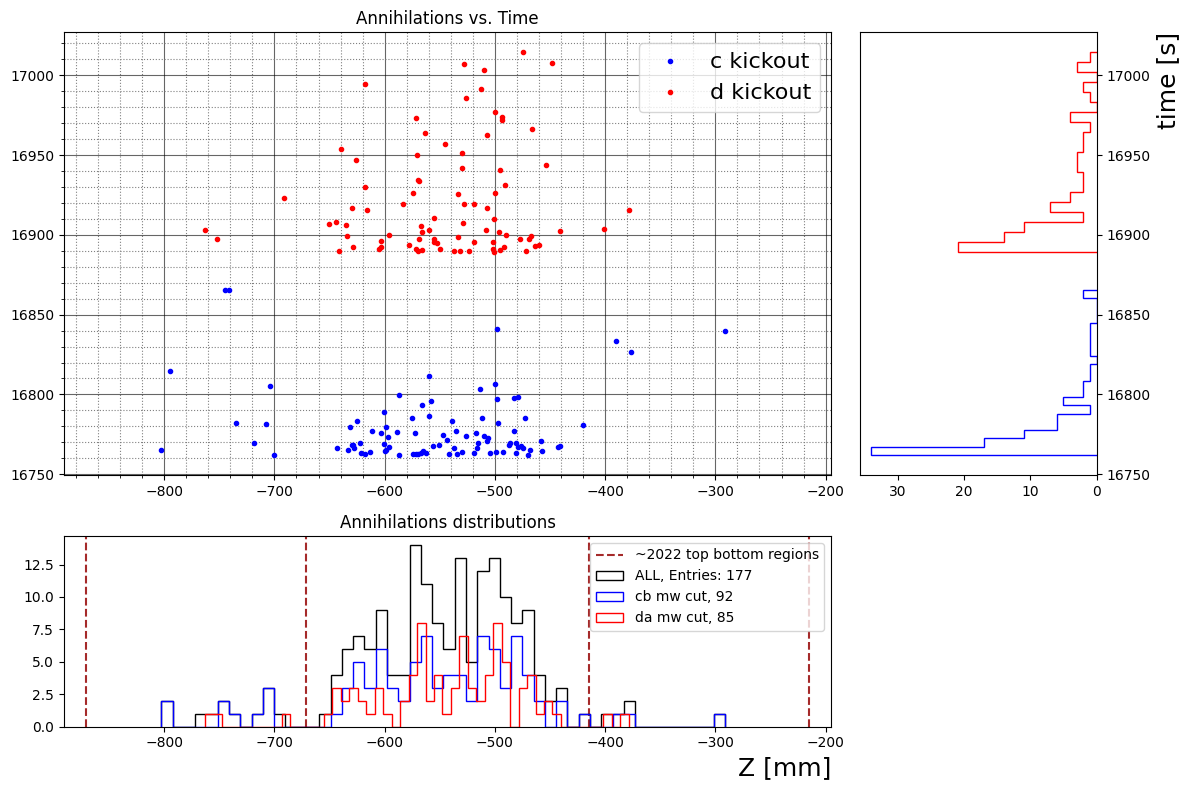

In [10]:
#plt.figure(0, figsize = (12, 8))
#plt.title("R13659, Adiabatic Expantion", fontsize = 20)
#plt.yticks(fontsize = 16)
#plt.xticks(fontsize = 16)

try:
    mask = (data["run time"] > start_knife_cb[0]) & (data["run time"] < stop_knife_da[0])
    maskcb = (data["run time"] > start_knife_cb[0]) & (data["run time"] < stop_knife_cb[0])
    maskda = (data["run time"] > start_knife_da[0]) & (data["run time"] < stop_knife_da[0])
    #Nup, Ndown = NupNdown(data, start_knife_cb[0], stop_knife_da[0], zmin, zmax, zgap_min, zgap_max)
except:
    mask = (data["run time"] > start_knife_cb[0]) & (data["run time"] < stop_knife_cb[0])
    maskcb = (data["run time"] > start_knife_cb[0]) & (data["run time"] < (start_knife_cb[0] + stop_knife_cb[0])/2)
    maskda = (data["run time"] > (start_knife_cb[0] + stop_knife_cb[0])/2) & (data["run time"] < stop_knife_cb[0])
    #Nup, Ndown = NupNdown(data, start_knife_cb[0], stop_knife_da[0], zmin, zmax, zgap_min, zgap_max)

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.set_title("Annihilations vs. Time")
#ax1.set_ylabel("time [s]", loc = "top", fontsize = 18)
try:
    ax1.errorbar(data["Z"][maskcb], data["run time"][maskcb] , color = "blue", marker = ".", linestyle = "", label = "c kickout")
    ax1.errorbar(data["Z"][maskda], data["run time"][maskda] , color = "red", marker = ".", linestyle = "", label = "d kickout")
except:
    ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", linestyle = "", label = f"Microwave Dump[0]")

ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
ax1.legend(fontsize = 16)
ax1.set_xlim(zmin-20,zmax+20)

# Annihilation Z distributions
ax2.set_title("Annihilations distributions")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.hist(data["Z"][mask], bins = 50, histtype = "step", color = "black", density = False, label = f"ALL, Entries: {mask.sum()}")
ax2.set_xlim(zmin-20,zmax+20)
try:
    ax2.hist(data["Z"][maskcb], bins = 50, histtype = "step", density = False, color = "blue", label = f"cb mw cut, {maskcb.sum()}")
    ax2.hist(data["Z"][maskda], bins = 50, histtype = "step", density = False, color = "red",  label = f"da mw cut, {maskda.sum()}")
except:
    print("Only one mw dumpt")

ax2.legend()

# Plot Time Distributions
try:
    ax3.hist(data["run time"][maskcb], bins = 20, histtype = "step", color = "blue", density = False, orientation='horizontal')
    ax3.hist(data["run time"][maskda], bins = 20, histtype = "step", color = "red", density = False, orientation='horizontal')
except:
    print("only one mw dump")
    ax3.hist(data["run time"][mask], bins = 20, histtype = "step", color = "black", density = False, orientation='horizontal')
    
#ax3.axhline(timecut, linestyle = "--", color = "black")
#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"MwKnife_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

60 60
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]
[767.8060014  164.75250641]


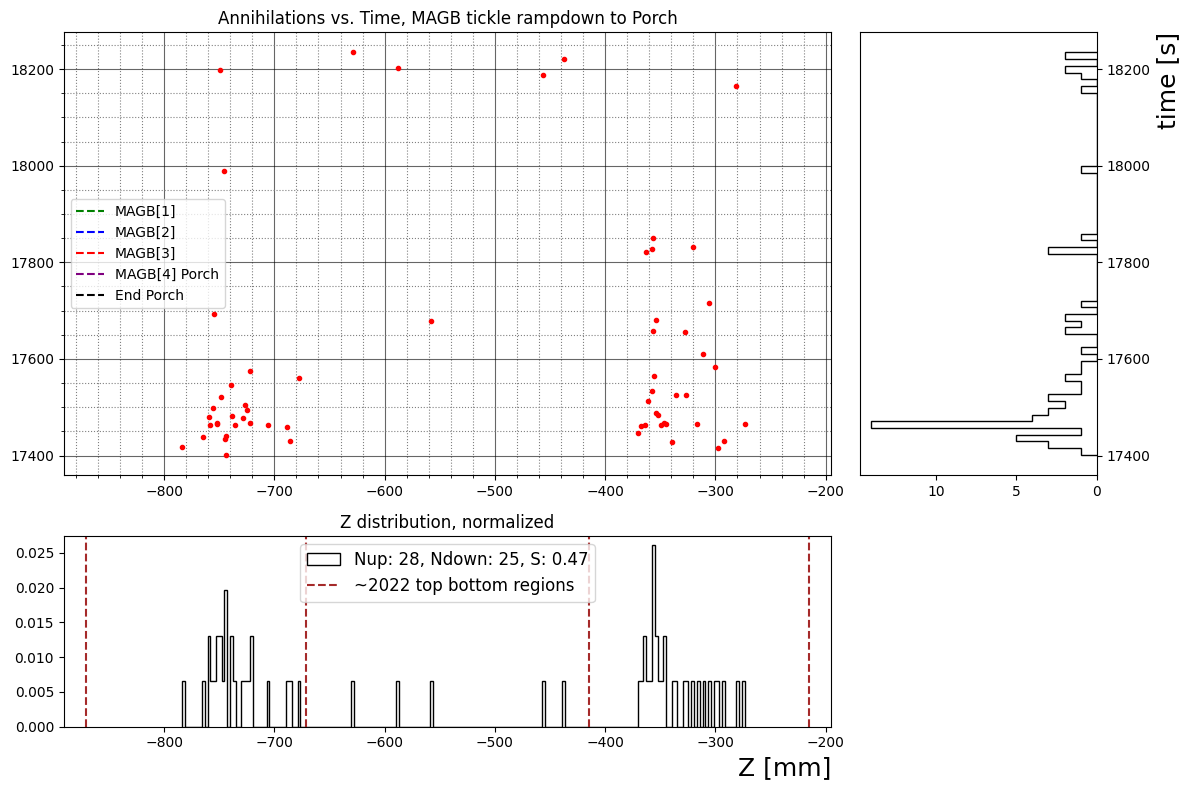

In [11]:
#plt.figure(0, figsize = (12, 8))
#plt.title("R13659, Adiabatic Expantion", fontsize = 20)
#plt.yticks(fontsize = 16)
#plt.xticks(fontsize = 16)

def expf(x, A, tau):
    return A*1/tau*np.exp(-x/tau)


timecut = stop_magb_rampdown[0] + 30

def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):

    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

mask = (data["run time"] > start_magb_rampdown1[0]) & (data["run time"] < stop_magb_rampdown4[0])
#mask_time = (data["run time"] > start_magb_rampdown[0]) & (data["run time"] < timecut)
#mask_time_neg = (data["run time"] < start_knife_cb[0]) & (data["run time"] > timecut)

Nup, Ndown = NupNdown(data, start_magb_rampdown1[0], stop_magb_rampdown4[0], zmin, zmax, zgap_min, zgap_max)

Nup = Nup - bkg_up * (stop_magb_rampdown4[0] - start_magb_rampdown1[0])
Ndown = Ndown - bkg_down * (stop_magb_rampdown4[0] - start_magb_rampdown1[0])

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.set_title("Annihilations vs. Time, MAGB tickle rampdown to Porch")

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "red", marker = ".", linestyle = "")
# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

ax1.axhline(start_magb_rampdown1[0], linestyle = "--", label = "MAGB[1]", color = "green")
ax1.axhline(stop_magb_rampdown1[0], linestyle = "--", color = "green")

ax1.axhline(start_magb_rampdown2[0], linestyle = "--", label = "MAGB[2]", color = "blue")
ax1.axhline(stop_magb_rampdown2[0], linestyle = "--", color = "blue")

ax1.axhline(start_magb_rampdown3[0], linestyle = "--", label = "MAGB[3]", color = "red")
ax1.axhline(stop_magb_rampdown3[0], linestyle = "--", color = "red")

ax1.axhline(start_magb_rampdown4[0], linestyle = "--", label = "MAGB[4] Porch", color = "purple")
ax1.axhline(stop_magb_rampdown4[0], linestyle = "--", label = "End Porch", color = "black")

#ax1.axhline(start_magb_rampdown1[0], linestyle = "--", label = "MAGB[1]", color = "green")
#ax1.axhline(start_magb_rampdown2[0], linestyle = "--", label = "MAGB[2]", color = "blue")
#ax1.axhline(start_magb_rampdown3[0], linestyle = "--", label = "MAGB[3]", color = "red")
#ax1.axhline(start_magb_rampdown4[0], linestyle = "--", label = "MAGB[4] Porch", color = "purple")
#ax1.axhline(stop_magb_rampdown4[0], linestyle = "--", label = "End Porch", color = "black")
ax1.legend()
ax1.set_xlim(zmin-20,zmax+20)


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
#ax2.hist(data["Z"][mask_time], bins = binning[0], histtype = "step", color = "orange", density = True,  label = f" < {timecut}s")
#ax2.hist(data["Z"][mask_time_neg], bins = binning[0], histtype = "step", color = "green", density = True,  label = f" > {timecut}s ")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)

counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')
print(len(bins[:-1]), len(counts))
mask_fit = (bins[:-1] > timecut)
print(mask_fit)
popt, pcovm = curve_fit(expf,(bins[:-1] - bins[0])[mask_fit], counts[mask_fit], p0 = [100, 20])
print(popt)
xgrid = np.linspace(bins[4], bins[-1], 100)
#print(xgrid)
#ax3.plot(expf(xgrid - xgrid[0], *popt),xgrid, linestyle = "--", color = "red" )

#ax3.axhline(timecut, linestyle = "--", color = "black")
#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"MagbRampDown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

25 25


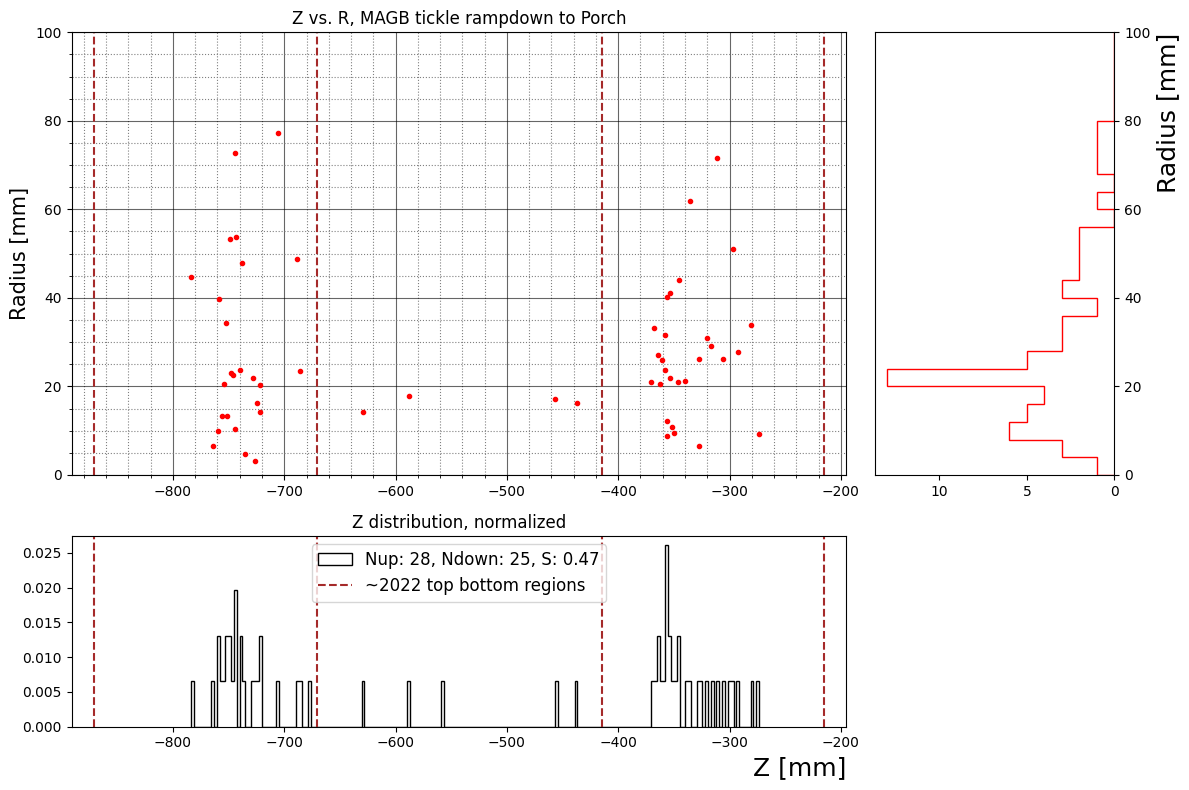

In [12]:
# compute the radius

data["R"] = np.sqrt(data["X"]**2 + data["Y"]**2)

timecut = stop_magb_rampdown[0] + 30

mask = (data["run time"] > start_magb_rampdown1[0]) & (data["run time"] < stop_magb_rampdown4[0])
#mask_time = (data["run time"] > start_magb_rampdown[0]) & (data["run time"] < timecut)
#mask_time_neg = (data["run time"] < start_knife_cb[0]) & (data["run time"] > timecut)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occupa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occupa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occupa 1 riga

ax1.set_title("Z vs. R, MAGB tickle rampdown to Porch")

ax1.errorbar(data["Z"][mask], data["R"][mask] , color = "red", marker = ".", linestyle = "")
# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

ax1.set_xlim(zmin-20,zmax+20)
ax1.set_ylim(0, 100)

ax1.set_ylabel("Radius [mm]", fontsize = 15)
ax1.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax1.axvline(zmax,linestyle = "--", color = "brown")
ax1.axvline(zgap_min,linestyle = "--", color = "brown")
ax1.axvline(zgap_max,linestyle = "--", color = "brown")


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
#ax2.hist(data["Z"][mask_time], bins = binning[0], histtype = "step", color = "orange", density = True,  label = f" < {timecut}s")
#ax2.hist(data["Z"][mask_time_neg], bins = binning[0], histtype = "step", color = "green", density = True,  label = f" > {timecut}s ")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)

counts, bins, _ = ax3.hist(data["R"][mask], bins = 25, range = (0, 100), histtype = "step", color = "red", density = False, orientation='horizontal')
print(len(bins[:-1]), len(counts))
ax3.set_ylim(0, 100)
ax3.set_ylabel("Radius [mm]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"RvsZ_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

25 25


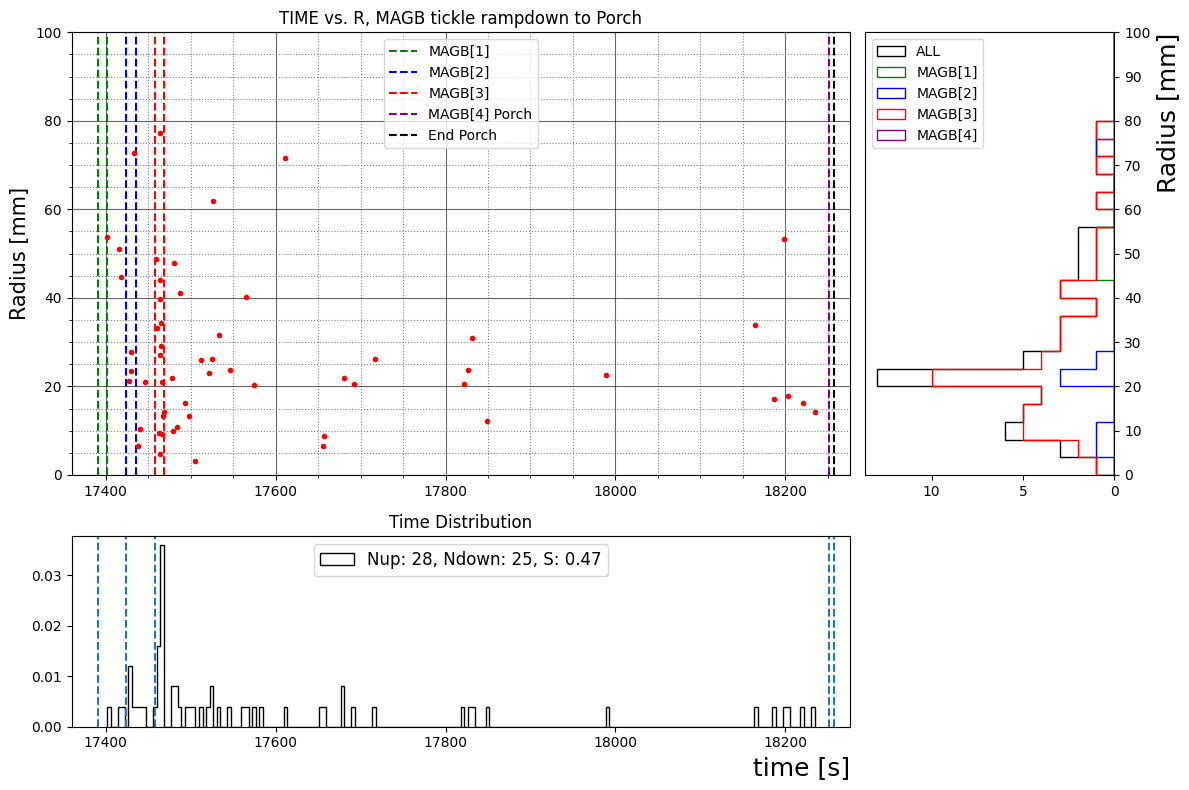

In [13]:
# compute the radius

data["R"] = np.sqrt(data["X"]**2 + data["Y"]**2)

mask = (data["run time"] > start_magb_rampdown1[0]) & (data["run time"] < stop_magb_rampdown4[0])

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occupa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occupa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occupa 1 riga

ax1.set_title("TIME vs. R, MAGB tickle rampdown to Porch")

ax1.errorbar(data["run time"][mask], data["R"][mask] , color = "red", marker = ".", linestyle = "")
# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
ax1.set_ylim(0, 100)
ax1.set_ylabel("Radius [mm]", fontsize = 15)

ax1.axvline(start_magb_rampdown1[0], linestyle = "--", label = "MAGB[1]", color = "green")
ax1.axvline(stop_magb_rampdown1[0], linestyle = "--", color = "green")

ax1.axvline(start_magb_rampdown2[0], linestyle = "--", label = "MAGB[2]", color = "blue")
ax1.axvline(stop_magb_rampdown2[0], linestyle = "--", color = "blue")

ax1.axvline(start_magb_rampdown3[0], linestyle = "--", label = "MAGB[3]", color = "red")
ax1.axvline(stop_magb_rampdown3[0], linestyle = "--", color = "red")

ax1.axvline(start_magb_rampdown4[0], linestyle = "--", label = "MAGB[4] Porch", color = "purple")
ax1.axvline(stop_magb_rampdown4[0], linestyle = "--", label = "End Porch", color = "black")
ax1.legend()

ax2.set_title("Time Distribution")
ax2.set_xlabel("time [s]", loc = "right", fontsize = 18)
ax2.hist(data["run time"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.legend(fontsize = 12)
ax2.axvline(start_magb_rampdown1[0], linestyle = "--")
ax2.axvline(start_magb_rampdown2[0], linestyle = "--")
ax2.axvline(start_magb_rampdown3[0], linestyle = "--")
ax2.axvline(start_magb_rampdown4[0], linestyle = "--")
ax2.axvline(stop_magb_rampdown4[0], linestyle = "--")


counts, bins, _ = ax3.hist(data["R"][mask], bins = 25, range = (0,100),  histtype = "step", color = "black", density = False, orientation='horizontal', label = "ALL")

mask_magb1 = (data["run time"] > start_magb_rampdown1[0]) & (data["run time"] < start_magb_rampdown2[0])
mask_magb2 = (data["run time"] > start_magb_rampdown2[0]) & (data["run time"] < start_magb_rampdown3[0])
mask_magb3 = (data["run time"] > start_magb_rampdown3[0]) & (data["run time"] < start_magb_rampdown4[0])
mask_magb4 = (data["run time"] > start_magb_rampdown4[0]) & (data["run time"] < stop_magb_rampdown4[0])

counts, bins, _ = ax3.hist(data["R"][mask_magb1], bins = 25, range = (0,100), histtype = "step", color = "green", density = False, orientation='horizontal', label = "MAGB[1]")
counts, bins, _ = ax3.hist(data["R"][mask_magb2], bins = 25, range = (0,100), histtype = "step", color = "blue", density = False, orientation='horizontal', label = "MAGB[2]")
counts, bins, _ = ax3.hist(data["R"][mask_magb3], bins = 25, range = (0,100), histtype = "step", color = "red", density = False, orientation='horizontal', label = "MAGB[3]")
counts, bins, _ = ax3.hist(data["R"][mask_magb4], bins = 25, range = (0,100), histtype = "step", color = "purple", density = False, orientation='horizontal', label = "MAGB[4]")

print(len(bins[:-1]), len(counts))
ax3.set_ylim(0, 100)
ax3.set_ylabel("Radius [mm]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.set_yticks(np.arange(0,110,10))
ax3.invert_xaxis()
ax3.legend()

plt.tight_layout()
plt.show()
fig.savefig(f"TimevsR_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# R, phi distributions

In [14]:
def cart2cyl(x, y, z, degrees=False):
    """
    Versione vettoriale (accetta float o array-like) basata su NumPy.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    r = np.hypot(x, y)
    phi = np.arctan2(y, x)                   # (-π, π]
    phi = np.mod(phi, 2 * np.pi)/np.pi       # [0, 2π)

    if degrees:
        phi = np.degrees(phi)

    return phi

In [15]:
data["phi"] = cart2cyl(data["X"], data["Y"], data["Z"])

25 25


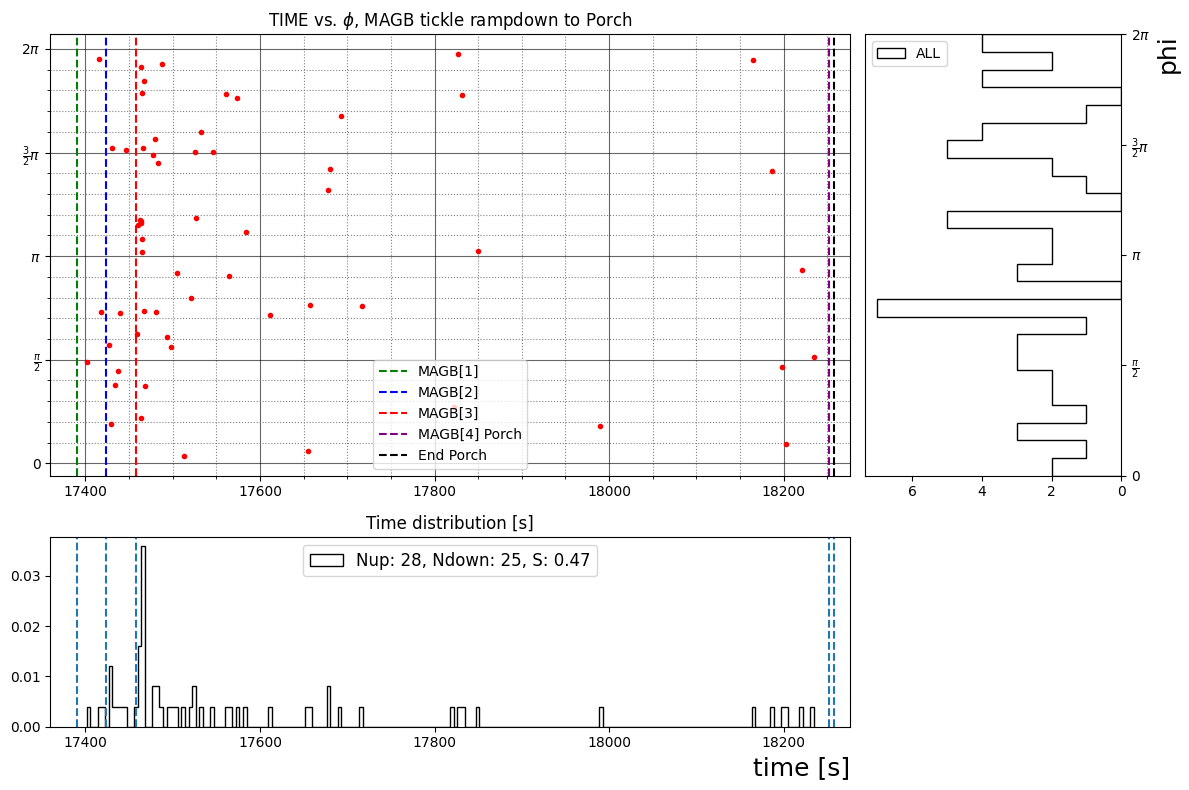

In [16]:
# compute the radius
mask = (data["run time"] > start_magb_rampdown1[0]) & (data["run time"] < stop_magb_rampdown4[0])

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occupa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occupa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occupa 1 riga

ax1.errorbar(data["run time"][mask], data["phi"][mask] , color = "red", marker = ".", linestyle = "")

ax1.set_title(r"TIME vs. $\phi$, MAGB tickle rampdown to Porch")
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigiaax1.set_ylim(0, 2)

ax1.set_yticks([0, 0.5, 1, 1.5, 2])
ax1.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])

#ax1.axvline(start_magb_rampdown[0], linestyle = "--", label = "MAGB[0]", color = "orange")
ax1.axvline(start_magb_rampdown1[0], linestyle = "--", label = "MAGB[1]", color = "green")
ax1.axvline(start_magb_rampdown2[0], linestyle = "--", label = "MAGB[2]", color = "blue")
ax1.axvline(start_magb_rampdown3[0], linestyle = "--", label = "MAGB[3]", color = "red")
ax1.axvline(start_magb_rampdown4[0], linestyle = "--", label = "MAGB[4] Porch", color = "purple")
ax1.axvline(stop_magb_rampdown4[0], linestyle = "--", label = "End Porch", color = "black")
ax1.legend()


ax2.hist(data["run time"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.set_title("Time distribution [s]")
ax2.set_xlabel("time [s]", loc = "right", fontsize = 18)
ax2.legend(fontsize = 12)
#ax2.axvline(start_magb_rampdown[0], linestyle = "--")
ax2.axvline(start_magb_rampdown1[0], linestyle = "--")
ax2.axvline(start_magb_rampdown2[0], linestyle = "--")
ax2.axvline(start_magb_rampdown3[0], linestyle = "--")
ax2.axvline(start_magb_rampdown4[0], linestyle = "--")
ax2.axvline(stop_magb_rampdown4[0], linestyle = "--")

counts, bins, _ = ax3.hist(data["phi"][mask], bins = 25, range = (0,2),  histtype = "step", color = "black", density = False, orientation='horizontal', label = "ALL")

mask_magb1 = (data["run time"] > start_magb_rampdown1[0]) & (data["run time"] < start_magb_rampdown2[0])
mask_magb2 = (data["run time"] > start_magb_rampdown2[0]) & (data["run time"] < start_magb_rampdown3[0])
mask_magb3 = (data["run time"] > start_magb_rampdown3[0]) & (data["run time"] < start_magb_rampdown4[0])
mask_magb4 = (data["run time"] > start_magb_rampdown4[0]) & (data["run time"] < stop_magb_rampdown4[0])

#counts, bins, _ = ax3.hist(data["phi"][mask_magb1], bins = 25, range = (0,100), histtype = "step", color = "green", density = False, orientation='horizontal', label = "MAGB[1]")
#counts, bins, _ = ax3.hist(data["phi"][mask_magb2], bins = 25, range = (0,100), histtype = "step", color = "blue", density = False, orientation='horizontal', label = "MAGB[2]")
#counts, bins, _ = ax3.hist(data["phi"][mask_magb3], bins = 25, range = (0,100), histtype = "step", color = "red", density = False, orientation='horizontal', label = "MAGB[3]")
#counts, bins, _ = ax3.hist(data["phi"][mask_magb4], bins = 25, range = (0,100), histtype = "step", color = "purple", density = False, orientation='horizontal', label = "MAGB[4]")

print(len(bins[:-1]), len(counts))
ax3.set_ylim(0, 2)
ax3.set_ylabel("phi", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")

ax3.set_yticks([0, 0.5, 1, 1.5, 2])
ax3.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])

ax3.invert_xaxis()
ax3.legend()

plt.tight_layout()
plt.show()
fig.savefig(f"TimevsPHI_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Glue the result in the Notebook and retrieve them later

In [17]:
Nup, Ndown = NupNdown(data, start_magb_rampdown1[0], stop_magb_rampdown4[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (stop_magb_rampdown4[0] - start_magb_rampdown1[0])
Ndown = Ndown - bkg_down * (stop_magb_rampdown4[0] - start_magb_rampdown1[0])
S = Ndown/(Nup + Ndown)
result = S
dResult = np.sqrt(abs(S*(1-S))/(Nup + Ndown))
sb.glue("my_result", [result, dResult])

###--------------------
# first segment
Nup, Ndown = NupNdown(data, start_magb_rampdown1[0], stop_magb_rampdown1[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (stop_magb_rampdown1[0] - start_magb_rampdown1[0])
Ndown = Ndown - bkg_down * (stop_magb_rampdown1[0] - start_magb_rampdown1[0])

if((Nup + Ndown) > 0):
    S = Ndown/(Nup + Ndown)
else:
    S = np.nan

result = S

if((Nup + Ndown) > 0):
    dResult = np.sqrt(abs(S*(1-S))/(Nup + Ndown))
else:
    dResult = np.nan

sb.glue("ramp1", [result, dResult])

###--------------------
# second segment
Nup, Ndown = NupNdown(data, start_magb_rampdown2[0], stop_magb_rampdown2[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (stop_magb_rampdown2[0] - start_magb_rampdown2[0])
Ndown = Ndown - bkg_down * (stop_magb_rampdown2[0] - start_magb_rampdown2[0])

if((Nup + Ndown) > 0):
    S = Ndown/(Nup + Ndown)
else:
    S = np.nan

result = S

if((Nup + Ndown) > 0):
    dResult = np.sqrt(abs(S*(1-S))/(Nup + Ndown))
else:
    dResult = np.nan

sb.glue("ramp2", [result, dResult])

###--------------------
# third segment
Nup, Ndown = NupNdown(data, start_magb_rampdown3[0], stop_magb_rampdown3[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (stop_magb_rampdown3[0] - start_magb_rampdown3[0])
Ndown = Ndown - bkg_down * (stop_magb_rampdown3[0] - start_magb_rampdown3[0])

if((Nup + Ndown) > 0):
    S = Ndown/(Nup + Ndown)
else:
    S = np.nan

result = S

if((Nup + Ndown) > 0):
    dResult = np.sqrt(abs(S*(1-S))/(Nup + Ndown))
else:
    dResult = np.nan

sb.glue("ramp3", [result, dResult])

###--------------------
# coldest segment
Nup, Ndown = NupNdown(data, stop_magb_rampdown3[0], start_magb_rampdown4[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (stop_magb_rampdown3[0] - start_magb_rampdown4[0])
Ndown = Ndown - bkg_down * (stop_magb_rampdown3[0] - start_magb_rampdown4[0])

if((Nup + Ndown) > 0):
    S = Ndown/(Nup + Ndown)
else:
    S = np.nan

result = S

if((Nup + Ndown) > 0):
    dResult = np.sqrt(abs(S*(1-S))/(Nup + Ndown))
else:
    dResult = np.nan

sb.glue("ramp4", [result, dResult])


# Retrieve all the counts passing selection and save in the notebook
Nup, Ndown = NupNdown(data, start_clear[0], stop_magb_rampdown4[0], zmin, zmax, zgap_min, zgap_max)
sb.glue("tot_counts", [TOT_RUN_counts.sum(), Nup, Ndown])

# Retrive the mw counts and save in the notebook
sb.glue("tot_knife", [maskcb.sum() + maskda.sum(), maskcb.sum(), maskda.sum()])